In [1]:
import sys
import os

# Ruta a la raíz del proyecto
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(project_root)

print(project_root)  # opcional para verificar

/home/lucas/Descargas/Ruido/ClassANoise


In [5]:
import numpy as np
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from core.ClassA import RFI_MakeEnvelopeDataClassA
from estimators.Estimadores import *
from matplotlib.gridspec import GridSpec

mpl.rc('font',family = 'Times New Roman')

In [2]:
#----------------------
#----------------------
r = 0.05
A = 0.05
Sigma_G_sq = 0.001
#----------------------

#---------------------------------------------------------------------
#---------------------------------------------------------------------
veces = 50
N = np.array([500,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000])
#N = np.array([500,1000,2000])
n = np.size(N)

X = np.array([500,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000])
#X = np.array([500,1000,2000])
#---------------------------------------------------------------------
#---------------------------------------------------------------------

In [3]:
# Inicializacion del vector A_ini
vec_A_ini       = np.zeros((veces,n))
vec_r_ini       = np.zeros((veces,n))
vec_Sigmag2_ini = np.zeros((veces,n))

# Inicializacion de los vectores del estimador INEMM
A_est_Luc       = np.zeros((veces,n))
Sigmag2_est_Luc = np.zeros((veces,n))
r_est_Luc       = np.zeros((veces,n))

# Inicializacion de vectores de estimaciones estimador Kanemoto
A_est_Kane      = np.zeros((veces,n))
K_est_Kane      = np.zeros((veces,n))
r_est_Kane      = np.zeros((veces,n))

# Inicializacion de vectores de estimaciones estimador Zabin
A_est_Zabin = np.zeros((veces,n))
K_est_Zabin = np.zeros((veces,n))

# Inicializacion de vectores de estimaciones estimador EM
A_est_EM = np.zeros((veces,n))
K_est_EM = np.zeros((veces,n))

for j in range(len(N)):
    print (j)
    for i in range(veces):
        print (i)
        env_data_Norm,env_data_DesNorm = RFI_MakeEnvelopeDataClassA(A,r,10,N[j],Sigma_G_sq)

        # Estimador inicial
        A_ini,Sigmag2_ini,r_ini = est_inicial(env_data_DesNorm)
        vec_A_ini[i,j]          = A_ini
        vec_Sigmag2_ini[i,j]    = Sigmag2_ini
        vec_r_ini[i,j]          = r_ini

        # Estimador INEMM
        A_est_Luc[i,j],Sigmag2_est_Luc[i,j],r_est_Luc[i,j],Numiter_Luc = Est_Param_ClassA_CDF(env_data_DesNorm,[A_ini,Sigmag2_ini,r_ini],100,0.0001)

        # Estimador Kanemoto
        A_est_Kane[i,j],r_est_Kane[i,j],K_est_Kane[i,j] = Est_Momentos_Kanemoto(env_data_Norm)

        # Estimador Zabin
        A_est_Zabin[i,j],K_est_Zabin[i,j] = Est_Momentos_Zabin_Poor(env_data_Norm)

        # Estimador EM
        A_est_EM[i,j],NumIter = RFI_EMParamA(N[j], 10, env_data_Norm,A_ini,A_ini*r_ini,9)
        A_errado,K_est_EM[i,j],NumIter = RFI_EMTwoParamEst(N[j], 10, env_data_Norm, A_ini, A_ini*r_ini)

print ('FIN')

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
2
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
3
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
4
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
5
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
6
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
7
0
1


In [10]:
# ------------------------------- Guardado de Datos ----------------------------------
# --------------------------- Vector de abscisas -------------------------------------
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/X.npy', X)

# ---------------------------- vectores estimador propuesto --------------------------
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/vec_A_ini.npy', vec_A_ini)
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/vec_r_ini.npy', vec_r_ini)
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/vec_r_ini.npy', vec_r_ini)

# ---------------------------- vectores estimador kanemoto ---------------------------
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/A_est_Kane.npy', A_est_Kane)
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/K_est_Kane.npy', K_est_Kane)
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/r_est_Kane.npy', r_est_Kane)

# ---------------------------- vectores estimador Zabin-Poor -------------------------
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/A_est_Zabin.npy', A_est_Zabin)
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/K_est_Zabin.npy', K_est_Zabin)

# ---------------------------- vectores estimador EM ---------------------------------
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/A_est_EM.npy', A_est_EM )
np.save('C:/Users/Celeste/Desktop/vectores_Figura_3_ESL/K_est_EM.npy', K_est_EM)

In [4]:
# ----------- Cálculo del error cuadrático medio en la est. de A -------------------
mse_est_simple  = np.sum((vec_A_ini - A)**2,axis=0)/veces
mse_est_Luc     = np.sum((A_est_Luc - A)**2,axis=0)/veces
mse_est_Kane    = np.sum((A_est_Kane - A)**2,axis=0)/veces
mse_est_Zabin   = np.sum((A_est_Zabin - A)**2,axis=0)/veces
mse_est_EM      = np.sum((A_est_EM - A)**2,axis=0)/veces

# ----------- Cálculo del error cuadrático medio en la est. de r -------------------
mse_est_simple_r = np.sum((vec_r_ini - r)**2,axis=0)/veces
mse_est_Luc_r    = np.sum((r_est_Luc - r)**2,axis=0)/veces
mse_est_Kane_r   = np.sum((r_est_Kane - r)**2,axis=0)/veces
mse_est_Zabin_r  = np.sum((K_est_Zabin/A_est_Zabin - r)**2,axis=0)/veces
mse_est_EM_r     = np.sum((K_est_EM/A_est_EM - r)**2,axis=0)/veces

# ----------- Cálculo del error cuadrático medio en la est. de r -------------------
mse_est_simple_sigma = np.sum((vec_Sigmag2_ini - Sigma_G_sq)**2,axis=0)/veces
mse_est_Luc_sigma    = np.sum((Sigmag2_est_Luc - Sigma_G_sq)**2,axis=0)/veces

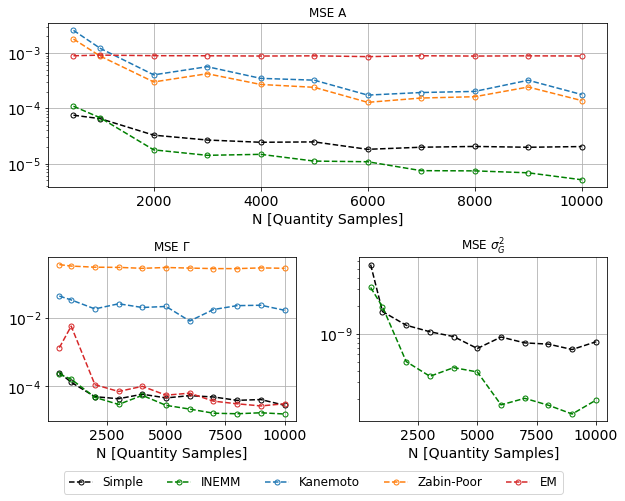

In [11]:
# -------------- FIGURAS -------------------------------------------------------------
# ------------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(8.8, 6.6))
gs0 = GridSpec(nrows=2, ncols=2)

ax0 = fig1.add_subplot(gs0[0, :])
ax0.set_yscale('log')
ax0.title.set_text(r'MSE A')
#ax0.set_ylabel(r'MSE A',fontsize = 14)
ax0.set_xlabel('N [Quantity Samples]',fontsize = 14)
ax0.plot(X,mse_est_simple, '--o', fillstyle = 'none', markersize = 5, color = 'black', label = 'Simple')
ax0.plot(X,mse_est_Luc, '--o', fillstyle = 'none', markersize = 5, color = 'green', label = 'INEMM')
ax0.plot(X,mse_est_Kane, '--o', fillstyle = 'none', markersize = 5, color = 'tab:blue', label = 'Kanemoto')
ax0.plot(X,mse_est_Zabin, '--o', fillstyle = 'none', markersize = 5, color = 'tab:orange', label = 'Zabin-Poor')
ax0.plot(X,mse_est_EM, '--o', fillstyle = 'none', markersize = 5, color = 'tab:red', label = 'EM')
ax0.grid(True)
ax0.tick_params(axis="x", labelsize=14)
ax0.tick_params(axis="y", labelsize=14)

#fig2 = plt.figure(figsize=(10, 5))
#gs1 = GridSpec(nrows=1, ncols=2)
#ax1 = fig2.add_subplot(gs1[0, 0])
ax1 = fig1.add_subplot(gs0[1, 0])
ax1.set_yscale('log')
ax1.title.set_text(r'MSE $\Gamma$')
#ax1.set_ylabel(r'MSE $\Gamma$',fontsize = 14)
ax1.set_xlabel('N [Quantity Samples]',fontsize = 14)
ax1.plot(X,mse_est_simple_r, '--o', fillstyle = 'none', markersize = 5, color = 'black', label = 'Simple')
ax1.plot(X,mse_est_Luc_r, '--o', fillstyle = 'none', markersize = 5, color = 'green', label = 'INEMM')
ax1.plot(X,mse_est_Kane_r, '--o', fillstyle = 'none', markersize = 5, color = 'tab:blue', label = 'Kanemoto')
ax1.plot(X,mse_est_Zabin_r, '--o', fillstyle = 'none', markersize = 5, color = 'tab:orange', label = 'Zabin-Poor')
ax1.plot(X,mse_est_EM_r, '--o', fillstyle = 'none', markersize = 5, color = 'tab:red', label = 'EM')
ax1.grid(True)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)

ax2 = fig1.add_subplot(gs0[1, 1])
ax2.set_yscale('log')
ax2.title.set_text(r'MSE $\sigma_{G}^{2}$')
#ax2.set_ylabel(r'MSE $\sigma_{G}^{2}$',fontsize = 14)
ax2.set_xlabel('N [Quantity Samples]',fontsize = 14)
ax2.plot(X,mse_est_simple_sigma, '--o', fillstyle = 'none', markersize = 5, color = 'black', label = 'Simple')
ax2.plot(X,mse_est_Luc_sigma, '--o', fillstyle = 'none', markersize = 5, color = 'green', label = 'INEMM')
ax2.grid(True)
ax2.tick_params(axis="x", labelsize=14)
ax2.tick_params(axis="y", labelsize=14)


#ax0.legend(loc = 1, fontsize = 14)
#ax1.legend(loc = 1, fontsize = 14)
#ax2.legend(loc = 1, fontsize = 14)

labels = ["Simple","INEMM","Kanemoto","Zabin-Poor","EM"]
fig1.legend(labels=labels,bbox_to_anchor=(0.5, -0.06),loc="lower center", ncol=5, fontsize = 12)
#fig1.legend(labels=labels, loc="lower center", ncol=2)

plt.tight_layout()
plt.show()
fig1.savefig('prueba1.pdf', bbox_inches = 'tight',pad_inches = 0.1)
#fig2.savefig('prueba2.pdf')